In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn
import tensorflow as tf

In [3]:
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

In [4]:
np.random.seed(180)
tf.random.set_seed(180)

(3023, 5655)
(3023,)


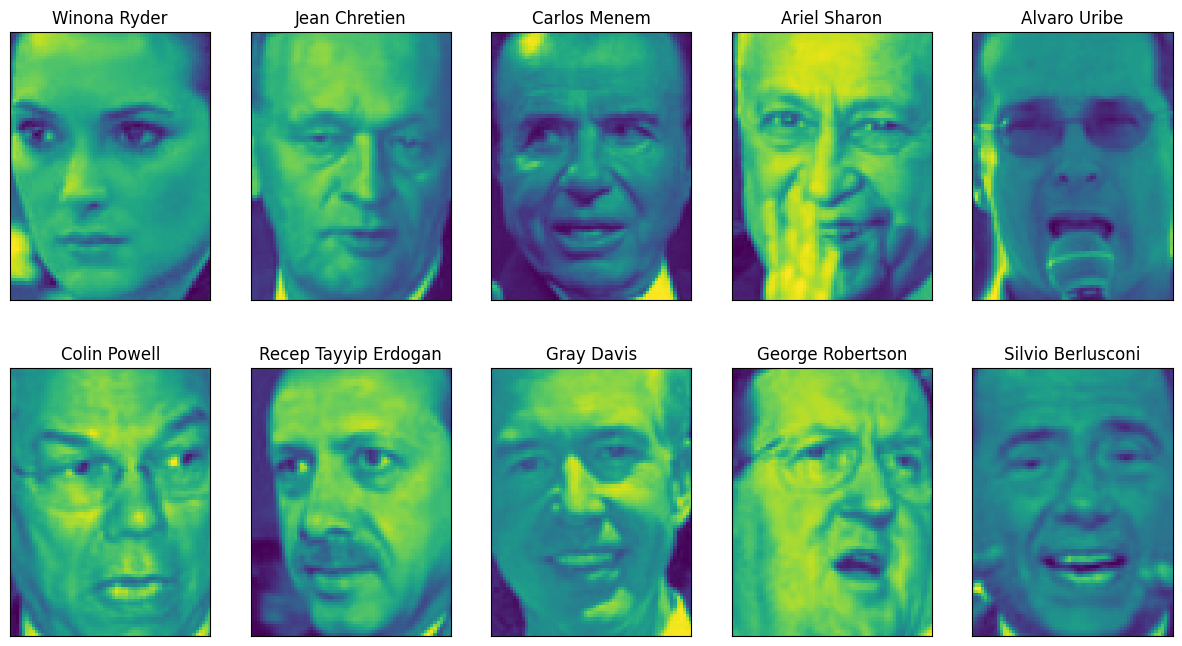

In [9]:
from sklearn.datasets import fetch_lfw_people
import matplotlib.pyplot as plt

people = fetch_lfw_people(
    min_faces_per_person=20,
    resize=0.7
)

print(people.data.shape)
print(people.target.shape)

image_shape = people.images[0].shape

# Display sample faces
fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 8),
    subplot_kw={'xticks': (), 'yticks': ()}
)

for target, image, ax in zip(
    people.target,
    people.images,
    axes.ravel()
):
    ax.imshow(image)
    ax.set_title(people.target_names[target])

plt.show()

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    people.data,
    people.target,
    test_size=0.2,
    random_state=20
)

y_train = y_train.astype(int)
y_test = y_test.astype(int)

batch_size = len(X_train)

print(
    X_train.shape,
    y_train.shape,
    y_test.shape
)

print(
    "people.images.shape: {}".format(
        people.images.shape
    )
)

print(
    "Number of classes: {}".format(
        len(people.target_names)
    )
)

(2418, 5655) (2418,) (605,)
people.images.shape: (3023, 87, 65)
Number of classes: 62


In [11]:
counts = np.bincount(people.target)

for i, (count, name) in enumerate(
    zip(counts, people.target_names)
):
    print(
        "{0:25} {1:3}".format(name, count),
        end=" "
    )
    
    if (i + 1) % 3 == 0:
        print()

Alejandro Toledo           39 Alvaro Uribe               35 Amelie Mauresmo            21 
Andre Agassi               36 Angelina Jolie             20 Ariel Sharon               77 
Arnold Schwarzenegger      42 Atal Bihari Vajpayee       24 Bill Clinton               29 
Carlos Menem               21 Colin Powell              236 David Beckham              31 
Donald Rumsfeld           121 George Robertson           22 George W Bush             530 
Gerhard Schroeder         109 Gloria Macapagal Arroyo    44 Gray Davis                 26 
Guillermo Coria            30 Hamid Karzai               22 Hans Blix                  39 
Hugo Chavez                71 Igor Ivanov                20 Jack Straw                 28 
Jacques Chirac             52 Jean Chretien              55 Jennifer Aniston           21 
Jennifer Capriati          42 Jennifer Lopez             21 Jeremy Greenstock          24 
Jiang Zemin                20 John Ashcroft              53 John Negroponte            31 

In [12]:
mask = np.zeros(
    people.target.shape,
    dtype=np.bool_
)

for target in np.unique(people.target):
    mask[
        np.where(people.target == target)[0][:50]
    ] = True

X_people = people.data[mask]
y_people = people.target[mask]

# Scale pixel values
X_people = X_people / 255.0

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_people,
    y_people,
    stratify=y_people,
    random_state=0
)

# KNN without PCA
knn = KNeighborsClassifier(
    n_neighbors=1
)

knn.fit(
    X_train,
    y_train
)

print(
    "Test set score of 1-nn: {:.2f}".format(
        knn.score(
            X_test,
            y_test
        )
    )
)

Test set score of 1-nn: 0.22


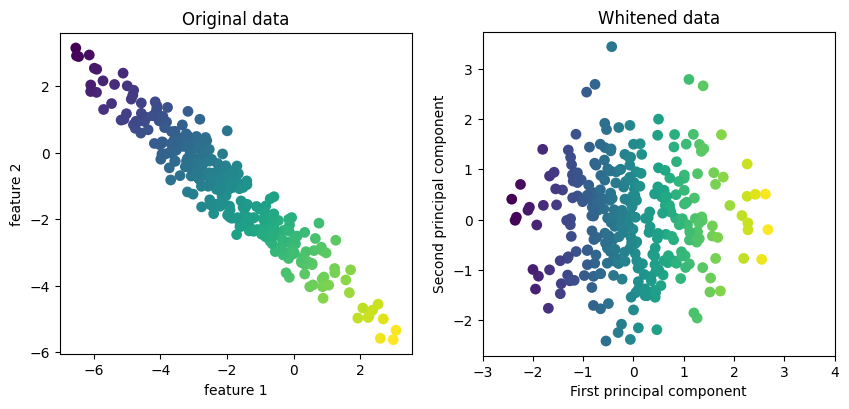

In [14]:
mglearn.plots.plot_pca_whitening()
plt.show()

In [15]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

pca = PCA(
    n_components=100,
    whiten=True,
    random_state=0
).fit(X_train)

X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

print(
    "X_train_pca.shape: {}".format(
        X_train_pca.shape
    )
)

# KNN with PCA
knn = KNeighborsClassifier(
    n_neighbors=1
)

knn.fit(
    X_train_pca,
    y_train
)

print(
    "Test set accuracy: {:.2f}".format(
        knn.score(
            X_test_pca,
            y_test
        )
    )
)

print(
    "pca.components_.shape: {}".format(
        pca.components_.shape
    )
)

X_train_pca.shape: (1547, 100)
Test set accuracy: 0.30
pca.components_.shape: (100, 5655)


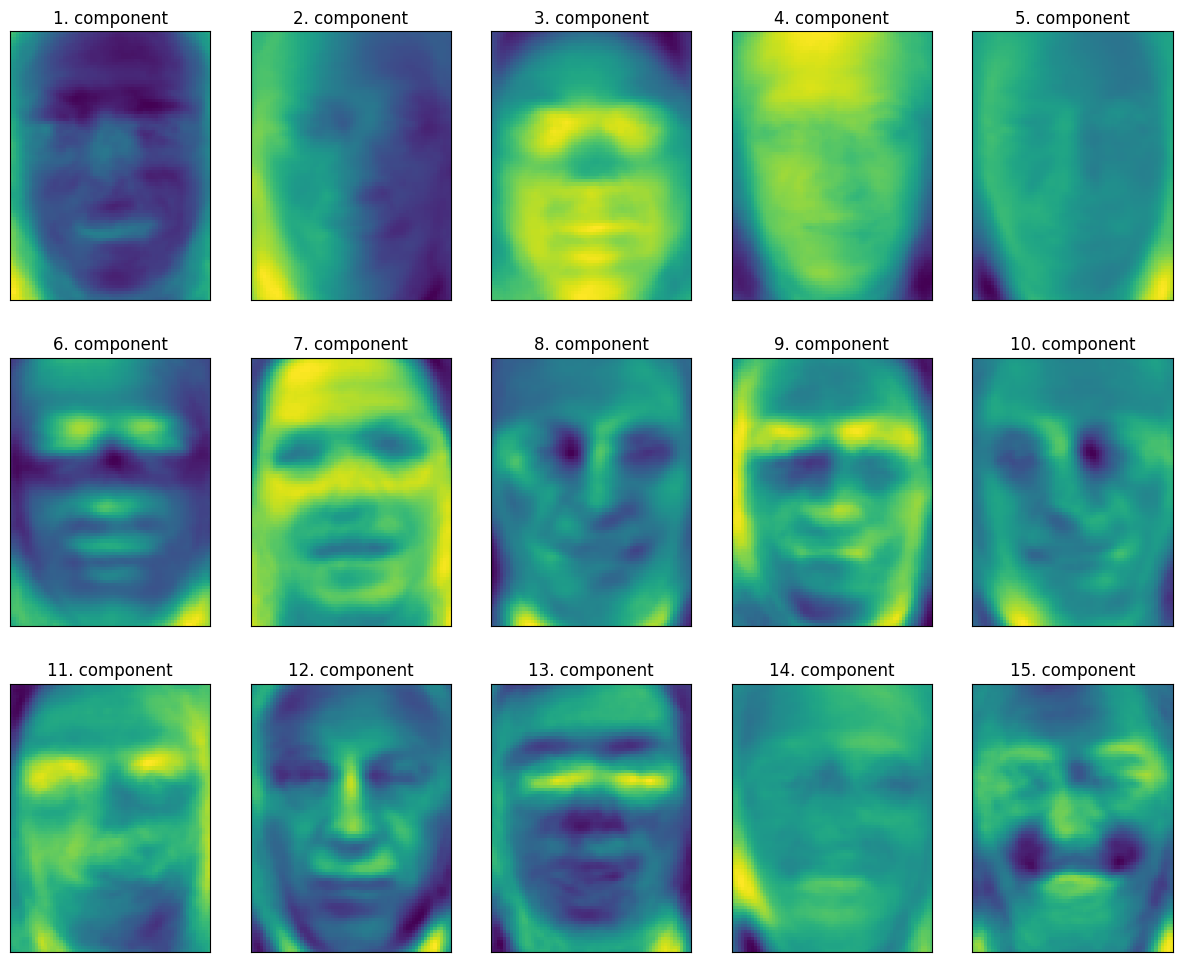

In [16]:
fig, axes = plt.subplots(
    3,
    5,
    figsize=(15, 12),
    subplot_kw={'xticks': (), 'yticks': ()}
)

for i, (component, ax) in enumerate(
    zip(pca.components_, axes.ravel())
):
    ax.imshow(
        component.reshape(image_shape),
        cmap='viridis'
    )
    ax.set_title(
        "{}. component".format(i + 1)
    )

plt.show()

In [17]:
from sklearn.preprocessing import MinMaxScaler

# Scaling PCA features
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(
    X_train_pca
)

X_test_scaled = scaler.transform(
    X_test_pca
)

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

model = Sequential([
    Input(shape=(100,)),
    Dense(
        300,
        activation='relu'
    ),
    Dense(
        100,
        activation='relu'
    ),
    Dense(
        len(np.unique(y_train)),
        activation='softmax'
    )
])

In [19]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [20]:
history = model.fit( X_train_scaled,y_train,batch_size=50,epochs=20,shuffle=False, verbose=1)

Epoch 1/20
31/31 [==============================] - 0s 1ms/step - loss: 4.1287 - accuracy: 0.0226
Epoch 2/20
31/31 [==============================] - 0s 816us/step - loss: 4.0857 - accuracy: 0.0265
Epoch 3/20
31/31 [==============================] - 0s 905us/step - loss: 4.0583 - accuracy: 0.0414
Epoch 4/20
31/31 [==============================] - 0s 822us/step - loss: 4.0322 - accuracy: 0.0452
Epoch 5/20
31/31 [==============================] - 0s 834us/step - loss: 3.9963 - accuracy: 0.0659
Epoch 6/20
31/31 [==============================] - 0s 819us/step - loss: 3.9534 - accuracy: 0.0827
Epoch 7/20
31/31 [==============================] - 0s 873us/step - loss: 3.8953 - accuracy: 0.1228
Epoch 8/20
31/31 [==============================] - 0s 836us/step - loss: 3.8210 - accuracy: 0.1616
Epoch 9/20
31/31 [==============================] - 0s 755us/step - loss: 3.7306 - accuracy: 0.1997
Epoch 10/20
31/31 [==============================] - 0s 814us/step - loss: 3.6167 - accuracy: 0.2198
E

In [21]:
loss, accuracy = model.evaluate( X_test_scaled,y_test,verbose=1)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

17/17 [==============================] - 0s 811us/step - loss: 2.6450 - accuracy: 0.3779
Test Loss: 2.6450295448303223
Test Accuracy: 0.3779069781303406
